# Ansatz Construction

In Variational Quantum Algorithms, the choice of the parameterized quantum circuit (Ansatz) is crucial. It determines the expressibility of the model and heavily influences trainability.

This notebook explores three common ways to construct an Ansatz in Qiskit.

In [1]:
from qiskit.circuit.library import RealAmplitudes, EfficientSU2
from qiskit.circuit import QuantumCircuit, ParameterVector
num_qubits = 3

### 1. RealAmplitudes Ansatz
`RealAmplitudes` consists of alternating layers of Ry rotations and CX entanglements. It restricts the amplitudes of the resulting statevector to real numbers (no imaginary parts), which is sufficient for problems with real Hamiltonians (like MaxCut).

/tmp/ipykernel_116103/2766734127.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  real_ansatz = RealAmplitudes(num_qubits, reps=2, entanglement='linear')


Number of parameters: 9


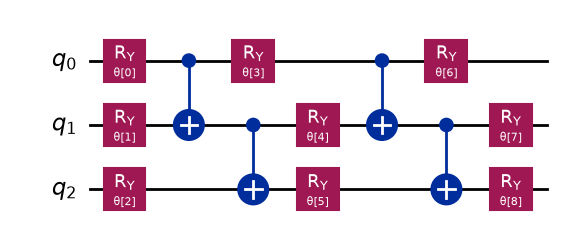

In [2]:
real_ansatz = RealAmplitudes(num_qubits, reps=2, entanglement='linear')
print(f"Number of parameters: {real_ansatz.num_parameters}")
real_ansatz.decompose().draw('mpl')

### 2. EfficientSU2 Ansatz
`EfficientSU2` consists of layers of single-qubit operations spanning SU(2) (typically Ry and Rz) followed by entangling gates. It can explore complex Hilbert spaces.

Number of parameters: 12


/tmp/ipykernel_116103/721398312.py:1: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  su2_ansatz = EfficientSU2(num_qubits, reps=1, entanglement='full')


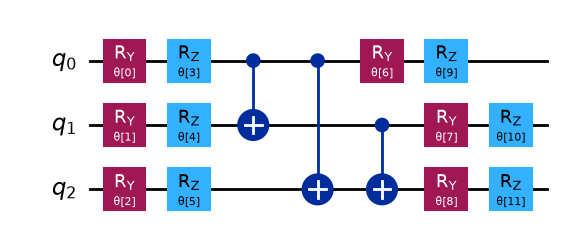

In [3]:
su2_ansatz = EfficientSU2(num_qubits, reps=1, entanglement='full')
print(f"Number of parameters: {su2_ansatz.num_parameters}")
su2_ansatz.decompose().draw('mpl')

### 3. Custom Ansatz with ParameterVector
Sometimes heuristic ansätze are not enough, and a problem-inspired ansatz is required.

Number of parameters: 4


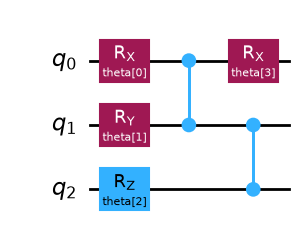

In [4]:
custom_ansatz = QuantumCircuit(num_qubits)
params = ParameterVector('theta', length=4)

custom_ansatz.rx(params[0], 0)
custom_ansatz.ry(params[1], 1)
custom_ansatz.rz(params[2], 2)
custom_ansatz.cz(0, 1)
custom_ansatz.cz(1, 2)
custom_ansatz.rx(params[3], 0)

print(f"Number of parameters: {custom_ansatz.num_parameters}")
custom_ansatz.draw('mpl')